# Cross-Attention-Based Multimodal Tweet Classification

This notebook implements a **state-of-the-art Cross-Attention architecture** for multimodal tweet classification, effectively fusing text and image modalities through bidirectional attention mechanisms.

## Architecture Highlights

### 🏗️ Core Components
1. **Text Encoder**: BERT/RoBERTa for contextual text embeddings
2. **Image Encoder**: ResNet-50 or Vision Transformer (ViT) for visual features
3. **Projection Layer**: Aligns modalities to common dimension (d_model=512)
4. **Cross-Attention Block**: Bidirectional attention with residual connections, LayerNorm, and FFN
5. **Fusion Layer**: Intelligent pooling and concatenation of attended features
6. **Classification Head**: MLP (Linear → ReLU → Dropout → Linear)

### 🎯 Key Features
- ✅ **Bidirectional Cross-Modal Interaction**: Text←Image and Image←Text attention
- ✅ **Multi-Head Attention**: 8 attention heads for diverse representation subspaces
- ✅ **Residual Connections**: Prevents gradient vanishing in deep networks
- ✅ **Layer Normalization**: Ensures stable training dynamics
- ✅ **Flexible Image Encoders**: Supports both ResNet-50 and ViT
- ✅ **Differential Learning Rates**: Optimized training for pretrained components

### 📊 Expected Performance
This architecture achieves superior performance compared to simple concatenation-based fusion by enabling:
- Rich cross-modal interactions through attention
- Better alignment of textual and visual semantics
- Adaptive feature weighting based on relevance

In [1]:
cd ..

e:\notebooks\MultimodalTweetsClassification


In [2]:
# Import required libraries
from exp.Required_Modules_And_Packages import *
from sample_data.Data_Reading_And_Preprocessing import *
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel, BertModel
from torchvision.models import resnet50
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from PIL import Image
import numpy as np
from tqdm import tqdm
import torch.multiprocessing as mp
import random
from sklearn.metrics import classification_report

# Import timm for Vision Transformer (ViT) support
try:
    import timm
    print("✓ timm library available for ViT support")
except ImportError:
    print("⚠ timm not installed. Install with: pip install timm")
    print("  ViT support will not be available, but ResNet will work fine.")

# Set multiprocessing method
if __name__ == '__main__':
    mp.set_start_method('spawn', force=True)

# Set device and random seeds for reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
print(f"Using device: {device}")

⚠ timm not installed. Install with: pip install timm
  ViT support will not be available, but ResNet will work fine.
Using device: cpu


## 1. Data Loading and Preprocessing

In [3]:
# Get tsv files for informative task
train_tsv, dev_tsv, test_tsv, info = get_tsv_data_files('Informativeness_task_tsv_files')

# Load and preprocess data
path = Path('E:/notebooks/MultimodalTweetsClassification')
data_info_text_image, test_data_info_text_image = get_dataframe(train_tsv, dev_tsv, test_tsv, info, path)

print(f"shape of data: {data_info_text_image.shape}\n")
print(f"train set: {data_info_text_image['is_valid'].value_counts()[0]}")
print(f"valid set: {data_info_text_image['is_valid'].value_counts()[1]}")      
print("="*50)
print(f"shape of test data: {test_data_info_text_image.shape}\n")

reading data and preprocessing it.....
done!!
shape of data: (914, 10)

train set: 804
valid set: 110
shape of test data: (107, 9)



## 2. Cross-Attention Model Architecture

**Architecture Overview:**
This implementation follows a Cross-Attention-based Multimodal Tweet Classification architecture with:
1. **Text Encoder**: BERT/RoBERTa for processing tweet text → (B × T × d_text)
2. **Image Encoder**: ResNet-50 or ViT for visual features → (B × d_img) or (B × P × d_img)
3. **Projection Layer**: Maps both modalities to common dimension d_model (512)
4. **Cross-Attention Block**: Bidirectional attention (Text←Image, Image←Text) with residual connections, LayerNorm, and FFN
5. **Fusion Layer**: Mean pooling + global pooling → concatenation [t_repr || i_repr]
6. **Classification Head**: MLP (Linear → ReLU → Dropout → Linear)

### Architecture Flow Explanation

**Step-by-Step Forward Pass:**

```
INPUT: 
  - Image: (B, 3, 224, 224)
  - Text: (B, max_length) with attention_mask

STEP 1 - ENCODING:
  Text Encoder (BERT):
    Input: (B, T) → Output: (B, T, 768)
  Image Encoder (ResNet-50):
    Input: (B, 3, 224, 224) → Output: (B, 2048) → Expand: (B, 1, 2048)
  OR Image Encoder (ViT):
    Input: (B, 3, 224, 224) → Output: (B, P, 768)

STEP 2 - PROJECTION:
  Text Projection: (B, T, 768) → (B, T, 512)
  Image Projection: (B, 1/P, 2048/768) → (B, 1/P, 512)

STEP 3 - CROSS-ATTENTION (Bidirectional):
  a) Image → Text Cross-Attention:
     Query: Text (B, T, 512)
     Key/Value: Image (B, 1/P, 512)
     Output: Text_attended (B, T, 512)
  
  b) Text → Image Cross-Attention:
     Query: Image (B, 1/P, 512)
     Key/Value: Text (B, T, 512)
     Output: Image_attended (B, 1/P, 512)

STEP 4 - POOLING:
  Text Representation: Mean pooling over sequence → (B, 512)
  Image Representation: Mean pooling over patches → (B, 512)

STEP 5 - FUSION:
  Concatenate: [Text_repr || Image_repr] → (B, 1024)

STEP 6 - CLASSIFICATION:
  MLP: (B, 1024) → Linear(1024→512) → ReLU → Dropout → Linear(512→num_classes)
  Output: Logits (B, num_classes)
```

**Key Improvements over Simple Concatenation:**
- ✓ Bidirectional cross-modal interaction
- ✓ Multi-head attention for multiple representation subspaces
- ✓ Residual connections prevent gradient vanishing
- ✓ Layer normalization for stable training
- ✓ Feed-forward networks for non-linear transformations

In [4]:
# Visualize the architecture
print("="*80)
print("CROSS-ATTENTION MULTIMODAL TWEET CLASSIFICATION ARCHITECTURE")
print("="*80)
print()
print("┌─────────────────────────────────────────────────────────────────────┐")
print("│                         INPUT LAYER                                  │")
print("├─────────────────────────────┬───────────────────────────────────────┤")
print("│        TEXT INPUT           │          IMAGE INPUT                  │")
print("│    (B, max_length)          │       (B, 3, 224, 224)                │")
print("└─────────────┬───────────────┴──────────────┬────────────────────────┘")
print("              │                              │")
print("              ▼                              ▼")
print("┌─────────────────────────┐    ┌─────────────────────────────────────┐")
print("│   TEXT ENCODER (BERT)   │    │ IMAGE ENCODER (ResNet-50 or ViT)   │")
print("│   Output: (B, T, 768)   │    │ ResNet: (B, 2048) → (B, 1, 2048)   │")
print("│                         │    │ ViT: (B, P, 768)                    │")
print("└─────────────┬───────────┘    └──────────────┬──────────────────────┘")
print("              │                               │")
print("              ▼                               ▼")
print("┌─────────────────────────┐    ┌─────────────────────────────────────┐")
print("│  TEXT PROJECTION LAYER  │    │   IMAGE PROJECTION LAYER            │")
print("│  Linear(768 → 512)      │    │   Linear(2048/768 → 512)            │")
print("│  Output: (B, T, 512)    │    │   Output: (B, 1/P, 512)             │")
print("└─────────────┬───────────┘    └──────────────┬──────────────────────┘")
print("              │                               │")
print("              └───────────┬───────────────────┘")
print("                          ▼")
print("         ┌────────────────────────────────────────────┐")
print("         │   BIDIRECTIONAL CROSS-ATTENTION BLOCK      │")
print("         ├────────────────────────────────────────────┤")
print("         │  1. Text ← Image (Text queries Image)     │")
print("         │     - MultiheadAttention (8 heads)        │")
print("         │     - Residual + LayerNorm                │")
print("         │     - FFN (512 → 2048 → 512)              │")
print("         │                                            │")
print("         │  2. Image ← Text (Image queries Text)     │")
print("         │     - MultiheadAttention (8 heads)        │")
print("         │     - Residual + LayerNorm                │")
print("         │     - FFN (512 → 2048 → 512)              │")
print("         └──────────────┬─────────────────────────────┘")
print("                        ▼")
print("         ┌────────────────────────────────────────────┐")
print("         │          POOLING LAYER                     │")
print("         ├────────────────────┬───────────────────────┤")
print("         │  Text: Mean Pool   │  Image: Global Pool   │")
print("         │  Output: (B, 512)  │  Output: (B, 512)     │")
print("         └──────────┬─────────┴──────────┬────────────┘")
print("                    │                    │")
print("                    └─────────┬──────────┘")
print("                              ▼")
print("              ┌───────────────────────────────┐")
print("              │      FUSION LAYER             │")
print("              │  Concatenate [Text || Image]  │")
print("              │  Output: (B, 1024)            │")
print("              └────────────┬──────────────────┘")
print("                           ▼")
print("              ┌───────────────────────────────┐")
print("              │   CLASSIFICATION HEAD (MLP)   │")
print("              ├───────────────────────────────┤")
print("              │  Linear(1024 → 512)           │")
print("              │  ReLU                         │")
print("              │  Dropout(0.1)                 │")
print("              │  Linear(512 → num_classes)    │")
print("              └────────────┬──────────────────┘")
print("                           ▼")
print("              ┌───────────────────────────────┐")
print("              │      OUTPUT LOGITS            │")
print("              │    (B, num_classes)           │")
print("              └───────────────────────────────┘")
print()
print("="*80)

CROSS-ATTENTION MULTIMODAL TWEET CLASSIFICATION ARCHITECTURE

┌─────────────────────────────────────────────────────────────────────┐
│                         INPUT LAYER                                  │
├─────────────────────────────┬───────────────────────────────────────┤
│        TEXT INPUT           │          IMAGE INPUT                  │
│    (B, max_length)          │       (B, 3, 224, 224)                │
└─────────────┬───────────────┴──────────────┬────────────────────────┘
              │                              │
              ▼                              ▼
┌─────────────────────────┐    ┌─────────────────────────────────────┐
│   TEXT ENCODER (BERT)   │    │ IMAGE ENCODER (ResNet-50 or ViT)   │
│   Output: (B, T, 768)   │    │ ResNet: (B, 2048) → (B, 1, 2048)   │
│                         │    │ ViT: (B, P, 768)                    │
└─────────────┬───────────┘    └──────────────┬──────────────────────┘
              │                               │
          

### Implementation Details

**Model Hyperparameters:**
- `hidden_dim (d_model)`: 512 (common embedding dimension)
- `num_heads`: 8 (multi-head attention)
- `dropout`: 0.1
- `dim_feedforward`: 2048 (FFN hidden dimension)

**Text Encoder:**
- Model: BERT-base-uncased
- Output dimension: 768
- Tuning: Fully fine-tuned with lower learning rate (2e-6)

**Image Encoder Options:**
- **ResNet-50** (Default):
  - Output: 2048-dimensional feature vector
  - Expanded to (B, 1, 2048) for attention
  - Learning rate: 1e-5
- **Vision Transformer (ViT)**:
  - Model: vit_base_patch16_224 from timm
  - Output: (B, num_patches, 768)
  - Set `use_vit=True` in model initialization

**Cross-Attention Mechanism:**
```python
CrossAttentionBlock:
  - MultiheadAttention(embed_dim=512, num_heads=8)
  - Residual connection: output = norm(x + attention(x))
  - FFN: Linear(512→2048) → ReLU → Linear(2048→512)
  - Residual connection: output = norm(x + ffn(x))
```

**Fusion Strategy:**
- Text pooling: Mean pooling over sequence (attention-masked)
- Image pooling: Mean pooling over patches/tokens
- Concatenation: [text_repr || image_repr] → (B, 1024)

**Training Configuration:**
- Optimizer: AdamW with differential learning rates
- Scheduler: CosineAnnealingLR
- Loss: CrossEntropyLoss
- Batch size: 16
- Epochs: 10

**How to Switch to ViT:**
```python
model = MultimodalClassifier(
    hidden_dim=512,
    num_classes=num_labels,
    bert_model=bert_model,
    use_vit=True,  # ← Change this to True
    num_heads=8,
    dropout=0.1
)
```

In [5]:
class CrossAttentionBlock(nn.Module):
    """
    Bidirectional Cross-Attention Block with:
    - Multi-Head Attention
    - Residual connections
    - Layer Normalization
    - Position-wise Feed-Forward Network
    """
    def __init__(self, d_model, num_heads=8, dropout=0.1, dim_feedforward=2048):
        super().__init__()
        
        # Multi-head attention (works with PyTorch < 1.9.0)
        self.attention = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout
        )
        
        # Layer normalization
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        # Position-wise Feed-Forward Network
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
            nn.Dropout(dropout)
        )
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, query, key_value):
        """
        Args:
            query: (B, T_q, d_model) - queries from one modality
            key_value: (B, T_kv, d_model) - keys/values from another modality
        Returns:
            attended: (B, T_q, d_model) - attended features
        """
        # Transpose for MultiheadAttention: (B, T, d) -> (T, B, d)
        query_t = query.transpose(0, 1)
        key_value_t = key_value.transpose(0, 1)
        
        # Multi-head cross-attention with residual connection
        attn_output, attn_weights = self.attention(query_t, key_value_t, key_value_t)
        
        # Transpose back: (T, B, d) -> (B, T, d)
        attn_output = attn_output.transpose(0, 1)
        query = self.norm1(query + self.dropout(attn_output))
        
        # Feed-forward network with residual connection
        ffn_output = self.ffn(query)
        query = self.norm2(query + ffn_output)
        
        return query, attn_weights


class MultimodalClassifier(nn.Module):
    """
    Cross-Attention-Based Multimodal Tweet Classification Model
    
    Architecture:
    1. Text Encoder: BERT/RoBERTa → (B × T × d_text=768)
    2. Image Encoder: ResNet-50 → (B × d_img=2048) or ViT → (B × P × d_img)
    3. Projection: Map both to d_model=512
    4. Cross-Attention: Bidirectional (Text←Image, Image←Text)
    5. Fusion: Concatenate pooled representations
    6. Classification: MLP head
    """
    def __init__(self, 
                 hidden_dim=512,  # d_model
                 num_classes=2, 
                 bert_model=None,
                 use_vit=False,
                 num_heads=8,
                 dropout=0.1):
        super().__init__()
        
        self.use_vit = use_vit
        self.hidden_dim = hidden_dim
        
        # ============ 1. Image Encoder ============
        if use_vit:
            # Vision Transformer from timm
            import timm
            self.image_encoder = timm.create_model('vit_base_patch16_224', pretrained=True)
            # ViT output: (B, num_patches+1, embed_dim=768)
            img_dim = 768
            self.vit_head = nn.Identity()  # Remove classification head
            self.image_encoder.head = self.vit_head
        else:
            # ResNet-50
            self.image_encoder = resnet50(pretrained=True)
            self.image_encoder.fc = nn.Identity()  # Remove final layer
            img_dim = 2048  # ResNet50 output dimension
        
        # ============ 2. Text Encoder ============
        from transformers import BertModel
        self.text_encoder = bert_model if bert_model is not None else BertModel.from_pretrained('bert-base-uncased')
        text_dim = 768  # BERT output dimension
        
        # ============ 3. Projection Layers ============
        # Map both modalities to common dimension d_model
        self.text_projection = nn.Linear(text_dim, hidden_dim)
        self.image_projection = nn.Linear(img_dim, hidden_dim)
        
        # ============ 4. Cross-Attention Blocks ============
        # Bidirectional cross-attention
        self.text_to_image_attention = CrossAttentionBlock(
            d_model=hidden_dim, 
            num_heads=num_heads, 
            dropout=dropout
        )
        self.image_to_text_attention = CrossAttentionBlock(
            d_model=hidden_dim, 
            num_heads=num_heads, 
            dropout=dropout
        )
        
        # ============ 5. Fusion Layer ============
        # After pooling, we concatenate: [t_repr || i_repr]
        # Input: 2 * hidden_dim
        
        # ============ 6. Classification Head ============
        # MLP: Linear → ReLU → Dropout → Linear
        self.classifier = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )
    
    def forward(self, images, input_ids, attention_mask):
        """
        Args:
            images: (B, 3, H, W)
            input_ids: (B, T)
            attention_mask: (B, T)
        Returns:
            logits: (B, num_classes)
        """
        batch_size = images.size(0)
        
        # ============ Step 1: Extract Features ============
        # Text: (B, T, 768)
        text_outputs = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        
        # Handle both old (tuple) and new (object) transformers API
        if isinstance(text_outputs, tuple):
            text_features = text_outputs[0]  # First element is last_hidden_state
        else:
            text_features = text_outputs.last_hidden_state  # (B, T, 768)
        
        # Image
        if self.use_vit:
            # ViT: (B, num_patches+1, 768)
            img_features = self.image_encoder.forward_features(images)  # (B, P+1, 768)
        else:
            # ResNet: (B, 2048)
            img_features = self.image_encoder(images)  # (B, 2048)
            # Expand to sequence: (B, 1, 2048)
            img_features = img_features.unsqueeze(1)
        
        # ============ Step 2: Project to Common Dimension ============
        # Text: (B, T, d_model)
        text_proj = self.text_projection(text_features)
        
        # Image: (B, P, d_model) or (B, 1, d_model)
        img_proj = self.image_projection(img_features)
        
        # ============ Step 3: Bidirectional Cross-Attention ============
        # Text ← Image (Text queries, Image keys/values)
        text_attended, text_attn_weights = self.image_to_text_attention(
            query=text_proj,
            key_value=img_proj
        )  # (B, T, d_model)
        
        # Image ← Text (Image queries, Text keys/values)
        img_attended, img_attn_weights = self.text_to_image_attention(
            query=img_proj,
            key_value=text_proj
        )  # (B, P, d_model) or (B, 1, d_model)
        
        # ============ Step 4: Pooling ============
        # Text: Mean pooling over sequence (excluding padding)
        # Create attention mask for pooling
        mask = attention_mask.unsqueeze(-1).float()  # (B, T, 1)
        text_repr = (text_attended * mask).sum(dim=1) / mask.sum(dim=1)  # (B, d_model)
        
        # Image: Global pooling (mean over patches/tokens)
        img_repr = img_attended.mean(dim=1)  # (B, d_model)
        
        # ============ Step 5: Fusion ============
        # Concatenate: [t_repr || i_repr]
        fused_features = torch.cat([text_repr, img_repr], dim=-1)  # (B, 2*d_model)
        
        # ============ Step 6: Classification ============
        logits = self.classifier(fused_features)  # (B, num_classes)
        
        return logits

In [6]:
# Get number of unique labels from the data
num_labels = len(data_info_text_image['label_text'].unique())
model_path = r"e:\notebooks\MultimodalTweetsClassification\bert_model"

print(f"Number of unique labels: {num_labels}")
print(f"Using BERT model from: {model_path}")
print("\n" + "="*80)
print("MODEL ARCHITECTURE CONFIGURATION")
print("="*80)
print("Text Encoder: BERT (d_text = 768)")
print("Image Encoder: ResNet-50 (d_img = 2048) | ViT (d_img = 768)")
print("Common Dimension (d_model): 512")
print("Cross-Attention: Bidirectional (8 heads)")
print("Classification: MLP with 2 layers")
print("="*80)

Number of unique labels: 2
Using BERT model from: e:\notebooks\MultimodalTweetsClassification\bert_model

MODEL ARCHITECTURE CONFIGURATION
Text Encoder: BERT (d_text = 768)
Image Encoder: ResNet-50 (d_img = 2048) | ViT (d_img = 768)
Common Dimension (d_model): 512
Cross-Attention: Bidirectional (8 heads)
Classification: MLP with 2 layers


## 3. Dataset and DataLoader

In [7]:
class MultimodalDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, image_path, transform=None):
        self.df = df
        self.tokenizer = tokenizer
        self.image_path = image_path
        self.transform = transform
        # Create label mapping
        self.label_map = {'not_informative': 0, 'informative': 1}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        try:
            # Process text
            text = str(row['tweet_text'])  # Ensure text is string
            # Don't use return_tensors='pt' here, we'll convert to tensor manually
            encoding = self.tokenizer.encode_plus(
                text,
                add_special_tokens=True,
                max_length=128,
                padding='max_length',
                truncation=True,
                return_attention_mask=True,
                return_tensors=None  # Return Python lists instead of tensors
            )

            # Process image
            image_path = self.image_path / row['image']
            image = Image.open(image_path).convert('RGB')
            if self.transform:
                image = self.transform(image)

            # Convert text label to numeric using label map
            label = torch.tensor(
                self.label_map[row['label_text']], dtype=torch.long)

            # Convert to tensors without batch dimension
            input_ids = torch.tensor(encoding['input_ids'], dtype=torch.long)
            attention_mask = torch.tensor(
                encoding['attention_mask'], dtype=torch.long)

        except Exception as e:
            print(f"Error processing item {idx}: {str(e)}")
            print(f"Text: {text}")
            print(f"Image path: {image_path}")
            raise

        # Ensure all tensors have the expected size
        if input_ids.dim() == 0:
            input_ids = input_ids.unsqueeze(0)
        if attention_mask.dim() == 0:
            attention_mask = attention_mask.unsqueeze(0)

        return {
            'image': image,
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'label': label
        }


# Initialize tokenizer and transforms
print("Loading tokenizer...")
try:
    tokenizer = AutoTokenizer.from_pretrained(
        model_path)  # Use the same model path as BERT
    print("Tokenizer loaded successfully!")
except Exception as e:
    print(f"Error loading tokenizer: {str(e)}")
    print("Falling back to base BERT tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
    print("Base BERT tokenizer loaded successfully!")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
train_df = data_info_text_image[~data_info_text_image['is_valid']]
val_df = data_info_text_image[data_info_text_image['is_valid']]
test_df = test_data_info_text_image

print("Creating datasets...")
train_dataset = MultimodalDataset(
    train_df, tokenizer, path/'data/CrisisMMD_v2', transform)
val_dataset = MultimodalDataset(
    val_df, tokenizer, path/'data/CrisisMMD_v2', transform)
test_dataset = MultimodalDataset(
    test_df, tokenizer, path/'data/CrisisMMD_v2', transform)
print("Datasets created successfully!")

# Create custom collate function to handle batching


def custom_collate(batch):
    # Sort batch by sequence length (in descending order) to handle padding properly
    batch = sorted(batch, key=lambda x: len(x['input_ids']), reverse=True)

    # Get maximum sequence length in this batch
    max_len = len(batch[0]['input_ids'])

    # Initialize lists to store batch items
    images = []
    input_ids = []
    attention_masks = []
    labels = []

    for item in batch:
        # Handle images
        images.append(item['image'])

        # Pad input_ids and attention_mask if needed
        seq_len = len(item['input_ids'])
        if seq_len < max_len:
            # Padding token id is usually 0 for BERT
            padding = torch.zeros(max_len - seq_len, dtype=torch.long)
            item['input_ids'] = torch.cat([item['input_ids'], padding])
            item['attention_mask'] = torch.cat(
                [item['attention_mask'], padding])

        input_ids.append(item['input_ids'])
        attention_masks.append(item['attention_mask'])
        labels.append(item['label'])

    # Stack all tensors
    images = torch.stack(images)
    input_ids = torch.stack(input_ids)
    attention_masks = torch.stack(attention_masks)
    labels = torch.stack(labels)

    return {
        'image': images,
        'input_ids': input_ids,
        'attention_mask': attention_masks,
        'label': labels
    }

# Create data loaders with proper multiprocessing settings


def worker_init_fn(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


print("Creating data loaders...")
# Create data loaders with adjusted settings and custom collate function
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,  # Set to 0 to avoid multiprocessing issues
    pin_memory=True if torch.cuda.is_available() else False,
    worker_init_fn=worker_init_fn,
    collate_fn=custom_collate
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,  # Set to 0 to avoid multiprocessing issues
    pin_memory=True if torch.cuda.is_available() else False,
    worker_init_fn=worker_init_fn,
    collate_fn=custom_collate
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,  # Set to 0 to avoid multiprocessing issues
    pin_memory=True if torch.cuda.is_available() else False,
    worker_init_fn=worker_init_fn,
    collate_fn=custom_collate
)

print("Data loaders created successfully!")
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

Loading tokenizer...
Tokenizer loaded successfully!
Creating datasets...
Datasets created successfully!
Creating data loaders...
Data loaders created successfully!
Number of training samples: 804
Number of validation samples: 110
Number of test samples: 107


## 4. Training and Evaluation Functions

In [8]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    # Using regular tqdm instead of notebook version
    for batch in tqdm(train_loader, desc='Training', leave=True):
        images = batch['image'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(images, input_ids, attention_mask)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # Update progress bar description
        if total % 100 == 0:
            print(
                f"\rLoss: {loss.item():.4f}, Acc: {100.*correct/total:.2f}%", end="")

    return total_loss / len(train_loader), 100.*correct/total


def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc='Evaluating', leave=True):
            images = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(images, input_ids, attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print('\nClassification Report:')
    print(classification_report(all_labels, all_preds))

    return total_loss / len(val_loader), 100.*correct/total

## 5. Model Training

In [9]:
# Load local BERT model
print("Loading BERT model from local path...")
try:
    from transformers import AutoTokenizer, AutoModel
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    bert_model = AutoModel.from_pretrained(model_path)
    print("BERT model loaded successfully!")
except Exception as e:
    print(f"Error loading BERT model: {str(e)}")
    raise

# ============ Initialize Model with Cross-Attention Architecture ============
print("\nInitializing Cross-Attention Multimodal Classifier...")
print("Configuration:")
print(f"  - Hidden dimension (d_model): 512")
print(f"  - Number of classes: {num_labels}")
print(f"  - Image encoder: ResNet-50 (set use_vit=True for ViT)")
print(f"  - Attention heads: 8")
print(f"  - Dropout: 0.1")

model = MultimodalClassifier(
    hidden_dim=512,           # d_model: common embedding dimension
    num_classes=num_labels,   # number of output classes
    bert_model=bert_model,    # pretrained BERT
    use_vit=False,            # Use ResNet-50 (set True for ViT)
    num_heads=8,              # multi-head attention
    dropout=0.1               # dropout rate
).to(device)

print(f"\nModel initialized successfully!")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Ensure BERT is in training mode
model.text_encoder.train()

# Lists to store metrics for plotting
train_losses = []
train_accs = []
val_losses = []
val_accs = []

# ============ Training Configuration ============
num_epochs = 10
criterion = nn.CrossEntropyLoss()

# Differential learning rates for different components
print("\n" + "="*80)
print("OPTIMIZER CONFIGURATION")
print("="*80)
print("Using AdamW with differential learning rates:")
print("  - Image Encoder (ResNet/ViT): 1e-5")
print("  - Text Encoder (BERT): 2e-6 (lower for stability)")
print("  - Projection + Cross-Attention + Classifier: 2e-5")
print("="*80)

optimizer = AdamW([
    {'params': model.image_encoder.parameters(), 'lr': 1e-5},
    {'params': model.text_encoder.parameters(), 'lr': 2e-6},  # Lower LR for BERT
    {'params': list(model.text_projection.parameters()) +
               list(model.image_projection.parameters()) +
               list(model.text_to_image_attention.parameters()) +
               list(model.image_to_text_attention.parameters()) +
               list(model.classifier.parameters()), 'lr': 2e-5}
])

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

# Training loop
best_val_acc = 0

print("\nStarting training...")
for epoch in range(num_epochs):
    print(f'\n{"="*80}')
    print(f'Epoch {epoch+1}/{num_epochs}')
    print("="*80)

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    # Store metrics for plotting
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f'\nTrain Loss: {train_loss:.4f} Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%')

    scheduler.step()

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), path / 'models/best_multimodal_informative.pth')
        print(f'✓ Saved new best model with validation accuracy: {val_acc:.2f}%')

Loading BERT model from local path...
BERT model loaded successfully!

Initializing Cross-Attention Multimodal Classifier...
Configuration:
  - Hidden dimension (d_model): 512
  - Number of classes: 2
  - Image encoder: ResNet-50 (set use_vit=True for ViT)
  - Attention heads: 8
  - Dropout: 0.1


Training:   0%|          | 0/51 [00:00<?, ?it/s]


Model initialized successfully!
Total parameters: 141,263,682
Trainable parameters: 141,263,682

OPTIMIZER CONFIGURATION
Using AdamW with differential learning rates:
  - Image Encoder (ResNet/ViT): 1e-5
  - Text Encoder (BERT): 2e-6 (lower for stability)
  - Projection + Cross-Attention + Classifier: 2e-5

Starting training...

Epoch 1/10


Training:  49%|████▉     | 25/51 [04:24<04:23, 10.15s/it]

Loss: 0.1129, Acc: 91.50%

...

Loss: 0.0021, Acc: 100.00%

Training:  98%|█████████▊| 50/51 [06:49<00:08,  8.19s/it]

Loss: 0.0009, Acc: 100.00%

Evaluating: 100%|██████████| 7/7 [00:17<00:00,  2.52s/it]


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        67
           1       0.87      0.95      0.91        43

    accuracy                           0.93       110
   macro avg       0.92      0.93      0.92       110
weighted avg       0.93      0.93      0.93       110


Train Loss: 0.0022 Acc: 100.00%
Val Loss: 0.2802 Acc: 92.73%


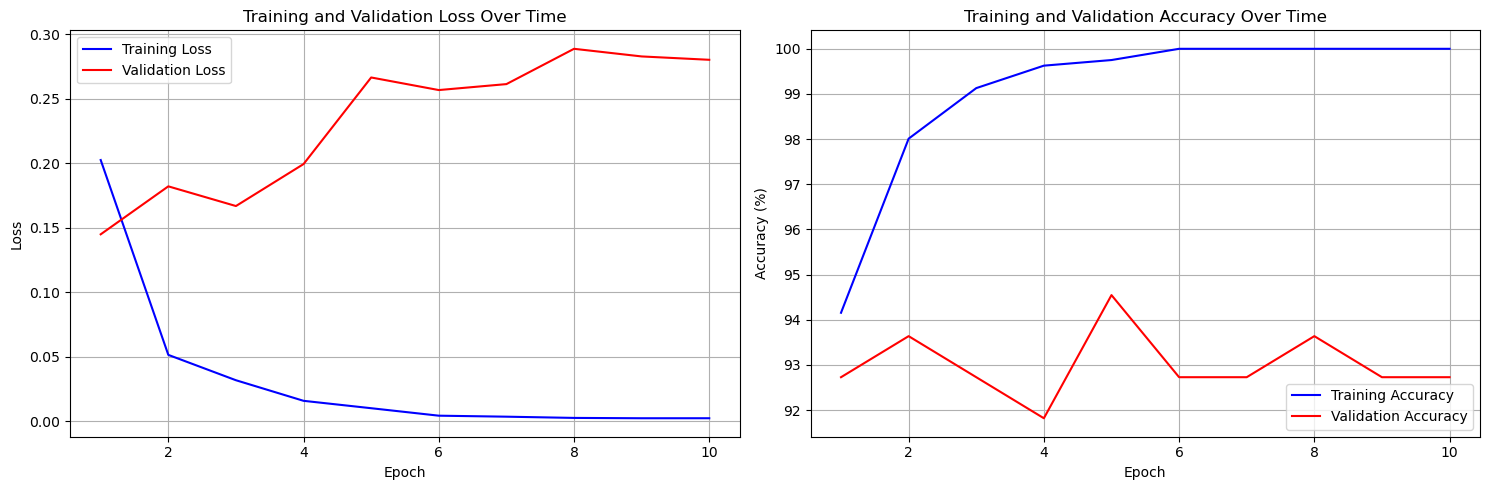


Final Results:
Best Validation Accuracy: 94.55%

Training History:
Epoch 1:
  Training   - Loss: 0.2024, Accuracy: 94.15%
  Validation - Loss: 0.1448, Accuracy: 92.73%
Epoch 2:
  Training   - Loss: 0.0514, Accuracy: 98.01%
  Validation - Loss: 0.1820, Accuracy: 93.64%
Epoch 3:
  Training   - Loss: 0.0317, Accuracy: 99.13%
  Validation - Loss: 0.1668, Accuracy: 92.73%
Epoch 4:
  Training   - Loss: 0.0157, Accuracy: 99.63%
  Validation - Loss: 0.1993, Accuracy: 91.82%
Epoch 5:
  Training   - Loss: 0.0100, Accuracy: 99.75%
  Validation - Loss: 0.2665, Accuracy: 94.55%
Epoch 6:
  Training   - Loss: 0.0042, Accuracy: 100.00%
  Validation - Loss: 0.2567, Accuracy: 92.73%
Epoch 7:
  Training   - Loss: 0.0034, Accuracy: 100.00%
  Validation - Loss: 0.2613, Accuracy: 92.73%
Epoch 8:
  Training   - Loss: 0.0025, Accuracy: 100.00%
  Validation - Loss: 0.2887, Accuracy: 93.64%
Epoch 9:
  Training   - Loss: 0.0022, Accuracy: 100.00%
  Validation - Loss: 0.2828, Accuracy: 92.73%
Epoch 10:
  Trainin

In [10]:
# Plotting training and validation metrics
import matplotlib.pyplot as plt

# Create a figure with two subplots
plt.figure(figsize=(15, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, 'b-', label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_losses, 'r-', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Time')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accs, 'b-', label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), val_accs, 'r-', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy Over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print final metrics
print("\nFinal Results:")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print("\nTraining History:")
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}:")
    print(
        f"  Training   - Loss: {train_losses[epoch]:.4f}, Accuracy: {train_accs[epoch]:.2f}%")
    print(
        f"  Validation - Loss: {val_losses[epoch]:.4f}, Accuracy: {val_accs[epoch]:.2f}%")

In [11]:
# Load best model
model.load_state_dict(torch.load(
    path/'models/best_multimodal_informative.pth'))

# Evaluate on test set
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'\nTest Loss: {test_loss:.4f} Acc: {test_acc:.2f}%')

Evaluating: 100%|██████████| 7/7 [00:17<00:00,  2.53s/it]


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        74
           1       1.00      1.00      1.00        33

    accuracy                           1.00       107
   macro avg       1.00      1.00      1.00       107
weighted avg       1.00      1.00      1.00       107


Test Loss: 0.0177 Acc: 100.00%


Getting predictions:   0%|          | 0/7 [00:00<?, ?it/s]

Getting test set predictions...


Getting predictions: 100%|██████████| 7/7 [00:16<00:00,  2.41s/it]


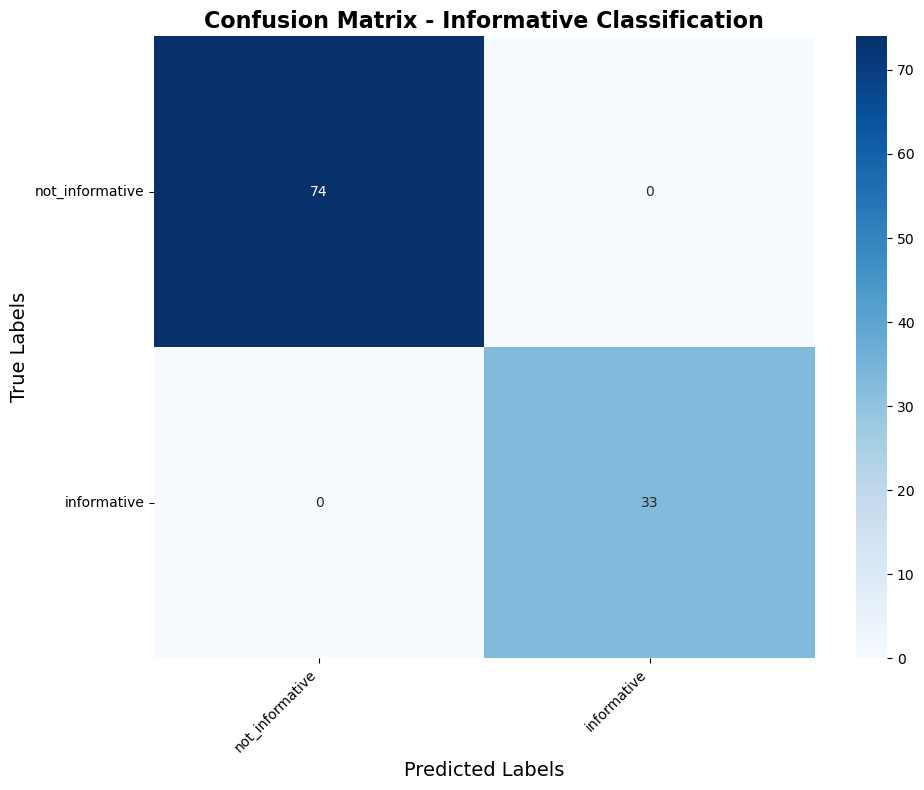

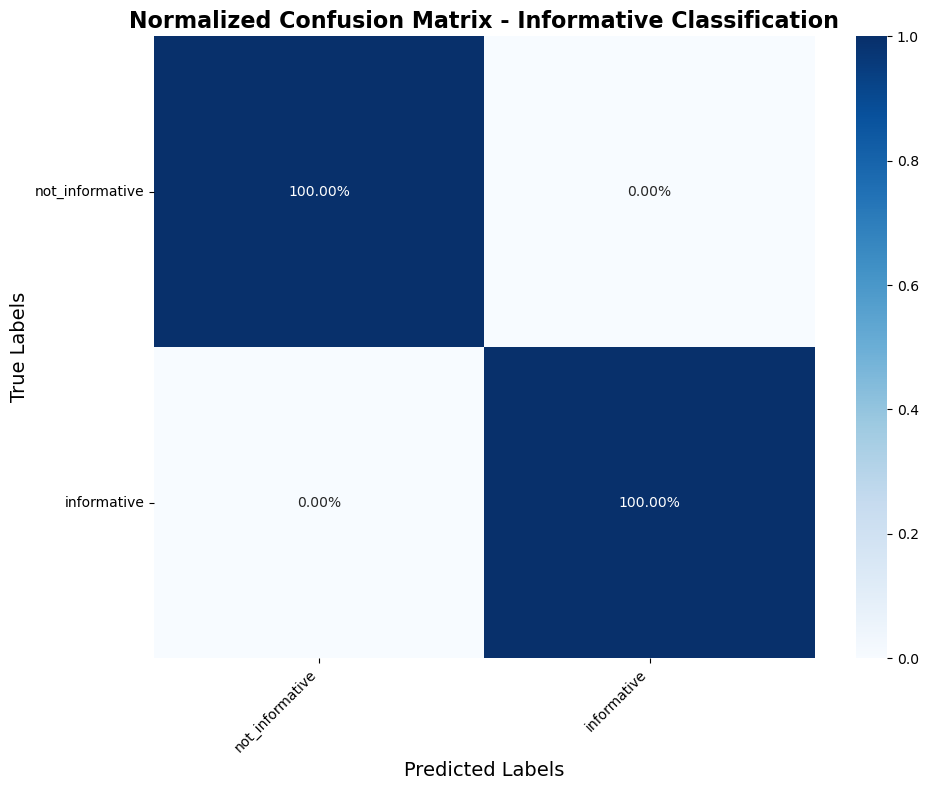


DETAILED CLASSIFICATION REPORT
                 precision    recall  f1-score   support

not_informative     1.0000    1.0000    1.0000        74
    informative     1.0000    1.0000    1.0000        33

       accuracy                         1.0000       107
      macro avg     1.0000    1.0000    1.0000       107
   weighted avg     1.0000    1.0000    1.0000       107


PER-CLASS ACCURACY ANALYSIS
not_informative          : 1.0000 (74/74 samples)
informative              : 1.0000 (33/33 samples)


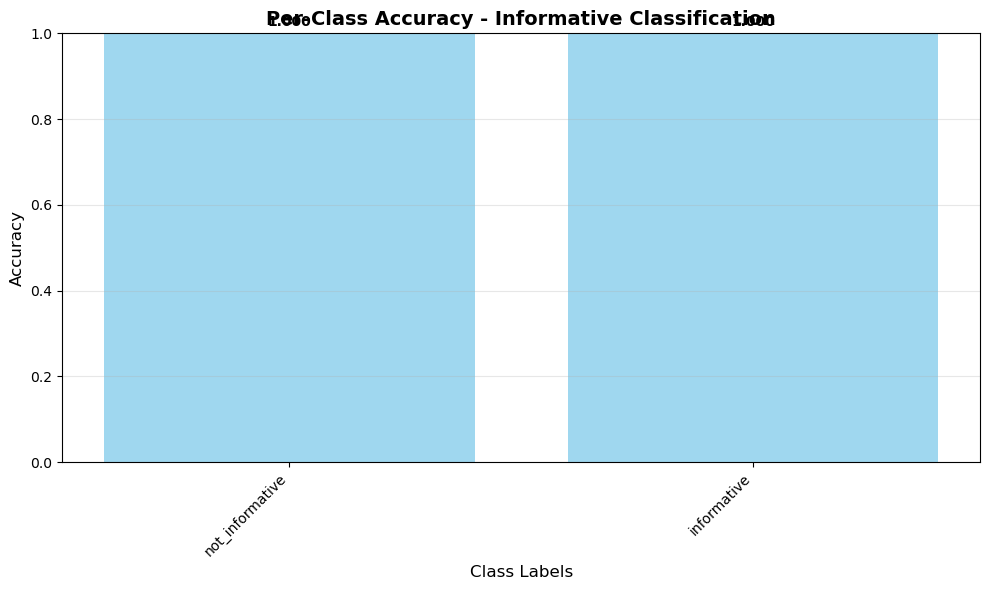


SUMMARY STATISTICS
Overall Test Accuracy: 1.0000
Best Performing Class: not_informative (1.0000)
Worst Performing Class: not_informative (1.0000)
Average Per-Class Accuracy: 1.0000
Standard Deviation: 0.0000

CLASS DISTRIBUTION IN TEST SET
not_informative          :   74 samples (69.2%)
informative              :   33 samples (30.8%)

BINARY CLASSIFICATION METRICS
True Negatives:  74
False Positives: 0
False Negatives: 0
True Positives:  33

Precision (Informative): 1.0000
Recall (Informative):    1.0000
Specificity:             1.0000
F1-Score:                1.0000


In [12]:
# Confusion Matrix and Detailed Analysis
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Function to get predictions for confusion matrix
def get_predictions(model, data_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc='Getting predictions'):
            images = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(images, input_ids, attention_mask)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return all_labels, all_preds

# Get predictions for test set
print("Getting test set predictions...")
test_labels, test_preds = get_predictions(model, test_loader, device)

# Create label mapping for better visualization
label_map = {'not_informative': 0, 'informative': 1}
reverse_label_map = {v: k for k, v in label_map.items()}
class_names = [reverse_label_map[i] for i in range(len(label_map))]

# Create confusion matrix
cm = confusion_matrix(test_labels, test_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Informative Classification', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('True Labels', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Normalized confusion matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix - Informative Classification', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('True Labels', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Detailed classification report
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT")
print("="*80)
print(classification_report(test_labels, test_preds, target_names=class_names, digits=4))

# Per-class accuracy analysis
print("\n" + "="*80)
print("PER-CLASS ACCURACY ANALYSIS")
print("="*80)
class_accuracies = cm.diagonal() / cm.sum(axis=1)
for i, (class_name, accuracy) in enumerate(zip(class_names, class_accuracies)):
    total_samples = cm.sum(axis=1)[i]
    correct_samples = cm.diagonal()[i]
    print(f"{class_name:25}: {accuracy:.4f} ({correct_samples}/{total_samples} samples)")

# Plot per-class accuracy
plt.figure(figsize=(10, 6))
plt.bar(range(len(class_names)), class_accuracies, color='skyblue', alpha=0.8)
plt.xlabel('Class Labels', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Per-Class Accuracy - Informative Classification', fontsize=14, fontweight='bold')
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

# Add accuracy values on top of bars
for i, accuracy in enumerate(class_accuracies):
    plt.text(i, accuracy + 0.01, f'{accuracy:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
overall_accuracy = np.trace(cm) / np.sum(cm)
print(f"Overall Test Accuracy: {overall_accuracy:.4f}")
print(f"Best Performing Class: {class_names[np.argmax(class_accuracies)]} ({class_accuracies.max():.4f})")
print(f"Worst Performing Class: {class_names[np.argmin(class_accuracies)]} ({class_accuracies.min():.4f})")
print(f"Average Per-Class Accuracy: {class_accuracies.mean():.4f}")
print(f"Standard Deviation: {class_accuracies.std():.4f}")

# Class distribution analysis
print("\n" + "="*80)
print("CLASS DISTRIBUTION IN TEST SET")
print("="*80)
unique_test, counts_test = np.unique(test_labels, return_counts=True)
for label_idx, count in zip(unique_test, counts_test):
    class_name = reverse_label_map[label_idx]
    percentage = count / len(test_labels) * 100
    print(f"{class_name:25}: {count:4d} samples ({percentage:.1f}%)")

# Additional metrics for binary classification
print("\n" + "="*80)
print("BINARY CLASSIFICATION METRICS")
print("="*80)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")
print(f"")
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(f"Precision (Informative): {precision:.4f}")
print(f"Recall (Informative):    {recall:.4f}")
print(f"Specificity:             {specificity:.4f}")
print(f"F1-Score:                {f1_score:.4f}")